# 🚀 WBS Tahap 6: Deployment & Policy Analysis
**Proyek:** Analisis Sentimen Ulasan Destinasi Wisata untuk Pengambilan Kebijakan Promosi Wisata pada Dinas Pariwisata dan Kebudayaan Kabupaten Garut  
**Tahapan WBS Terkait:**
1. **Analisis distribusi sentimen berdasarkan destinasi wisata (272 destinasi aktif)**
2. **Interpretasi hasil untuk memahami kecenderungan persepsi wisatawan**
3. **Penyusunan informasi pendukung pengambilan kebijakan promosi wisata**
4. **Penerapan 4 klasifikasi kebijakan dinas (*Promotional*, *Intervention*, *Monitoring*, *Insufficient Evidence*)**
5. **Penyajian hasil analisis dalam dashboard interaktif menggunakan Streamlit**

---
### Output Tahap Ini:
Dashboard interaktif Streamlit, dataset rekomendasi kebijakan destinasi wisata Kabupaten Garut, dan informasi pendukung pengambilan keputusan Dinas Pariwisata.


In [1]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

import sys
import os
import warnings
import joblib
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

CURRENT_DIR = Path.cwd()
ROOT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

from config import settings
from policy.analysis import generate_policy_recommendations

print(f"✅ Root Project Directory: {ROOT_DIR}")
print("Modul analisis kebijakan & visualisasi deployment siap.")


✅ Root Project Directory: /Users/macbook/Garut-Tourism-Reccomendation
Modul analisis kebijakan & visualisasi deployment siap.


## 1. Prediksi Sentimen & Agregasi Metrik per Destinasi Wisata

Hasil inferensi klasifikasi model Linear SVM diterapkan pada seluruh 17.923 ulasan valid untuk menghasilkan agregasi statistik sentimen pada **272 destinasi wisata aktif** di Kabupaten Garut.


In [2]:
# 1. Pemuatan Dataset Terprediksi / Menjalankan Prediksi
pred_path = settings.FINAL_DATA_DIR / "predicted_reviews.csv"

if pred_path.exists():
    df_pred = pd.read_csv(pred_path)
else:
    from sentiment.prediction import predict_dataset_sentiment
    df_labeled = pd.read_csv(settings.FINAL_DATA_DIR / "labeled_reviews.csv")
    model = joblib.load(ROOT_DIR / "models/svm_model.joblib")
    vectorizer = joblib.load(ROOT_DIR / "models/tfidf_vectorizer.joblib")
    df_pred = predict_dataset_sentiment(df_labeled, model, vectorizer)

print(f"✅ Total Ulasan Terprediksi: {len(df_pred):,} ulasan")
print(f"📍 Total Destinasi Teruji  : {df_pred['destination_name'].nunique():,} destinasi")


✅ Total Ulasan Terprediksi: 17,923 ulasan
📍 Total Destinasi Teruji  : 272 destinasi


## 2. Klasifikasi 4 Kategori Rekomendasi Kebijakan Dinas Pariwisata

Sistem menerapkan kriteria hierarki keputusan formal untuk mengelompokkan setiap destinasi ke dalam **4 Kategori Kebijakan Strategis**:

1. **`Insufficient Evidence` (Bukti Belum Cukup)**:
   - Destinasi dengan **total ulasan valid $< 10$**.
   - *Tindakan Dinas*: Mendorong sosialisasi digital dan pengumpulan ulasan awal sebelum intervensi promosi besar.
2. **`Intervention Priority` (Prioritas Perbaikan/Intervensi)**:
   - Destinasi dengan **persentase sentimen negatif $\ge 15.0\%$**.
   - *Tindakan Dinas*: Audit fasilitas, perbaikan akses jalan, kebersihan toilet, transparansi tarif parkir/tiket.
3. **`Promotional Priority` (Prioritas Promosi Unggulan)**:
   - Destinasi dengan **persentase sentimen positif $\ge 70.0\%$** dan **rata-rata rating $\ge 4.0$**.
   - *Tindakan Dinas*: Penguatan kampanye promosi digital skala provinsi/nasional sebagai destinasi unggulan Garut.
4. **`Monitoring / Improvement Priority` (Prioritas Pemantauan/Peningkatan)**:
   - Destinasi di luar ketiga kriteria di atas (kategori menengah dengan ulasan memadai namun potensi positif belum optimal).
   - *Tindakan Dinas*: Pemantauan tren berkala dan peningkatan fasilitas penunjang.


In [3]:
# Eksekusi Pembentukan Rekomendasi Kebijakan
generate_policy_recommendations(df_pred)
dest_policy_df = pd.read_csv(settings.FINAL_DATA_DIR / "destination_sentiment_summary.csv")
cat_policy_df = pd.read_csv(settings.FINAL_DATA_DIR / "category_sentiment_summary.csv")

policy_counts = dest_policy_df["policy_class"].value_counts()
tabel_kebijakan = pd.DataFrame({
    "Prioritas Kebijakan Dinas": policy_counts.index,
    "Jumlah Destinasi": policy_counts.values,
    "Persentase (%)": [f"{(v/len(dest_policy_df))*100:.2f}%" for v in policy_counts.values],
    "Contoh Destinasi Terpilih": [
        dest_policy_df[dest_policy_df["policy_class"] == p]["destination_name"].iloc[0]
        for p in policy_counts.index
    ]
})

display(tabel_kebijakan)


,Prioritas Kebijakan Dinas,Jumlah Destinasi,Persentase (%),Contoh Destinasi Terpilih
0,Promotional Priority,136,50.00%,AGROWISATA TEPAS PAPANDAYAN (ATP)
1,Insufficient Evidence,104,38.24%,Air panas muara talaga
2,Intervention Priority,28,10.29%,Asep Stroberi Kadungora
3,Monitoring / Improvement Priority,4,1.47%,Taman Kuliner CIbatu


## 3. Visualisasi Hasil Analisis Kebijakan Promosi Wisata

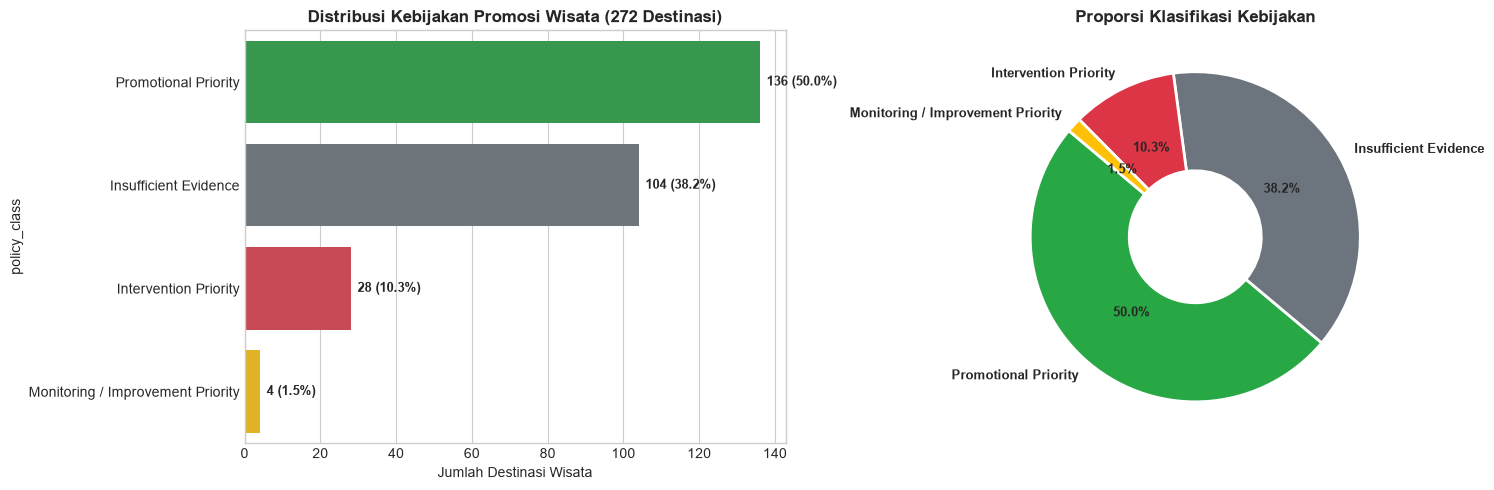

In [4]:
# Visualisasi Rekomendasi Kebijakan
fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=100)

# Grafik 1: Bar Chart Sebaran Kebijakan
colors = {"Promotional Priority": "#28a745", "Insufficient Evidence": "#6c757d", "Intervention Priority": "#dc3545", "Monitoring / Improvement Priority": "#ffc107"}
bar_colors = [colors.get(p, "#17a2b8") for p in policy_counts.index]

sns.barplot(x=policy_counts.values, y=policy_counts.index, palette=bar_colors, ax=axes[0])
axes[0].set_title("Distribusi Kebijakan Promosi Wisata (272 Destinasi)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Jumlah Destinasi Wisata", fontsize=10)
for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(f'{int(width)} ({width/len(dest_policy_df)*100:.1f}%)', (width, p.get_y() + p.get_height() / 2.),
                      ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9, fontweight="bold")

# Grafik 2: Donut Chart Proporsi Kebijakan
axes[1].pie(
    policy_counts.values,
    labels=policy_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=bar_colors,
    wedgeprops=dict(width=0.6, edgecolor='w', linewidth=2),
    textprops=dict(fontsize=9, fontweight="bold")
)
axes[1].set_title("Proporsi Klasifikasi Kebijakan", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


In [5]:
# TABEL TOP 10 DESTINASI PROMOTIONAL PRIORITY (UNGGULAN)
top_promo = dest_policy_df[dest_policy_df["policy_class"] == "Promotional Priority"].sort_values(
    by=["total_reviews", "positive_percentage"], ascending=[False, False]
).head(10)[["destination_name", "total_reviews", "average_rating", "positive_percentage", "negative_percentage"]]

top_promo.columns = ["Nama Destinasi", "Total Ulasan", "Rata-rata Rating", "% Positif", "% Negatif"]
top_promo["% Positif"] = top_promo["% Positif"].map("{:.2f}%".format)
top_promo["% Negatif"] = top_promo["% Negatif"].map("{:.2f}%".format)
top_promo["Rata-rata Rating"] = top_promo["Rata-rata Rating"].map("★ {:.2f}".format)

print("🏆 TOP 10 DESTINASI WISATA PRIORITAS PROMOSI (PROMOTIONAL PRIORITY):")
display(top_promo)


🏆 TOP 10 DESTINASI WISATA PRIORITAS PROMOSI (PROMOTIONAL PRIORITY):


,Nama Destinasi,Total Ulasan,Rata-rata Rating,% Positif,% Negatif
185,Ramenkane Cikuray Garut,398,★ 4.90,98.74%,0.75%
181,"RM Saung Cikenceh (Garut Kota, Cikuray)",383,★ 4.70,93.99%,4.70%
15,Bumi Upi,375,★ 4.50,82.67%,9.87%
84,"Joglo Abah Resto, Kedai Kopi dan Pusat Oleh-oleh",370,★ 4.90,96.76%,2.43%
69,Garland Barnville,350,★ 4.40,83.14%,12.86%
12,Botram Garut,349,★ 4.60,87.39%,7.74%
71,Glamping Villa by Sabda Alam,333,★ 4.90,96.40%,1.80%
184,Ramen Gorilla,311,★ 4.40,93.89%,4.50%
198,Rumah Makan Lumbung Padi Garut,311,★ 4.50,82.64%,13.18%
201,Rumah Makan Sunda - Dapoer Nyunda,310,★ 5.00,97.74%,1.61%


In [6]:
# TABEL TOP 10 DESTINASI INTERVENTION PRIORITY (PERBAIKAN)
top_interv = dest_policy_df[dest_policy_df["policy_class"] == "Intervention Priority"].sort_values(
    by=["negative_percentage", "total_reviews"], ascending=[False, False]
).head(10)[["destination_name", "total_reviews", "average_rating", "positive_percentage", "negative_percentage"]]

top_interv.columns = ["Nama Destinasi", "Total Ulasan", "Rata-rata Rating", "% Positif", "% Negatif"]
top_interv["% Positif"] = top_interv["% Positif"].map("{:.2f}%".format)
top_interv["% Negatif"] = top_interv["% Negatif"].map("{:.2f}%".format)
top_interv["Rata-rata Rating"] = top_interv["Rata-rata Rating"].map("★ {:.2f}".format)

print("⚠️ TOP 10 DESTINASI WISATA PRIORITAS INTERVENSI (INTERVENTION PRIORITY):")
display(top_interv)


⚠️ TOP 10 DESTINASI WISATA PRIORITAS INTERVENSI (INTERVENTION PRIORITY):


,Nama Destinasi,Total Ulasan,Rata-rata Rating,% Positif,% Negatif
195,Rumah Makan Kencana Sunda,47,★ 4.00,38.30%,55.32%
246,Warung Bambu garut,31,★ 4.20,41.94%,54.84%
247,Waterboom Tirta Kencana,33,★ 4.00,54.55%,39.39%
243,WISATA BINAR ALAM VIEW,24,★ 4.30,58.33%,37.50%
97,Kedai Itikurih,132,★ 4.30,59.09%,33.33%
199,Rumah Makan Megawati,12,★ 4.40,66.67%,33.33%
104,Kolam renang cipanas indah,25,★ 4.00,60.00%,32.00%
214,Sentral kuliner ikan garut,19,★ 4.10,68.42%,31.58%
87,Kampung Muara Sunda,402,★ 4.20,66.42%,29.60%
101,Kolam Renang dANAU DARIZA,11,★ 4.30,63.64%,27.27%


## 4. Penyajian Hasil Analisis dalam Dashboard Interaktif Streamlit

Seluruh model, dataset terprediksi, dan tabel rekomendasi kebijakan diintegrasikan ke dalam antarmuka web interaktif berbasis **Streamlit** ([app.py](file:///Users/macbook/Garut-Tourism-Reccomendation/app.py)).

### Fitur Utama Dashboard Streamlit:
1. **Ringkasan Eksekutif & Metrik KPI**: Total destinasi teruji, total ulasan, akurasi model SVM, dan sebaran 4 kebijakan dinas.
2. **Eksplorasi Spasial & Peta Interaktif**: Visualisasi peta sebaran lokasi destinasi pariwisata Garut dengan penanda warna sesuai kategori kebijakan.
3. **Filter Destinasi & Rekomendasi Kebijakan**: Pencarian detail per destinasi dengan grafik pie chart sentimen, tren rating, dan WordCloud ulasan.
4. **Simulator Prediksi Teks Real-time**: Memungkinkan staf dinas memasukkan teks ulasan baru untuk diprediksi sentimennya secara langsung menggunakan model Linear SVM.


In [7]:
# Panduan Menjalankan Dashboard Streamlit
print("Untuk menjalankan Dashboard Interaktif Streamlit, jalankan perintah berikut di terminal:")
print("👉 .venv/bin/streamlit run app.py")


Untuk menjalankan Dashboard Interaktif Streamlit, jalankan perintah berikut di terminal:
👉 .venv/bin/streamlit run app.py


## 5. Kesimpulan Tahap Deployment & Policy Analysis

1. **Implementasi Kebijakan Pariwisata**:
   - Dari 272 destinasi teruji, **136 destinasi (50.00%)** masuk kategori *Promotional Priority*, **104 destinasi (38.24%)** *Insufficient Evidence*, **28 destinasi (10.29%)** *Intervention Priority*, dan **4 destinasi (1.47%)** *Monitoring / Improvement Priority*.
2. **Dampak Praktis bagi Dinas Pariwisata Garut**:
   - Memberikan dasar keputusan berbasis bukti empiris (*evidence-based policy making*) dalam mengalokasikan anggaran promosi pariwisata dan perbaikan infrastruktur wisata.
3. **Deployment**:
   - Sistem siap dioperasikan melalui dashboard Streamlit yang intuitif.
